# House Price Prediction and Explanation - Comprehensive Analysis
# Ames, Iowa Housing Dataset

**Author:** Data Science Team  
**Date:** November 2025  
**Objective:** Build interpretable machine learning models to predict house prices and provide actionable insights through comprehensive data analysis, feature engineering, and explainability visualizations.

---

## Table of Contents
15. [Make Prediction from Test Set](#section15)
16. [Local Explainability with SHAP](#section16)
17. [Make Prediction and Explain with SHAP from User Input](#section17)

---

In [14]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
import joblib
import pickle
import shap
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100

print("="*80)
print("LOADING DATA FROM NB1 AND NB2 CACHE")
print("="*80)

# Check cache directory
cache_dir = Path('cache')

if not cache_dir.exists():
    print("\n❌ ERROR: Cache directory not found!")
    print("Please run NB1 and NB2 first to generate the required data.")
    raise FileNotFoundError("Cache directory 'cache/' not found. Run NB1 and NB2 first.")

# Load data from NB1
print("\nLoading NB1 outputs...")
train_engineered = pd.read_pickle(cache_dir / 'train_engineered.pkl')
test_engineered = pd.read_pickle(cache_dir / 'test_engineered.pkl')
train_df = pd.read_pickle(cache_dir / 'train_df.pkl')
test_df = pd.read_pickle(cache_dir / 'test_df.pkl')

with open(cache_dir / 'nb1_metadata.pkl', 'rb') as f:
    nb1_metadata = pickle.load(f)

RANDOM_STATE = nb1_metadata['RANDOM_STATE']
np.random.seed(RANDOM_STATE)

print("✓ Loaded from NB1:")
print(f"  - train_engineered: {train_engineered.shape}")
print(f"  - test_engineered: {test_engineered.shape}")
print(f"  - train_df: {train_df.shape}")
print(f"  - test_df: {test_df.shape}")

# Load data from NB2
print("\nLoading NB2 outputs...")
best_xgb = joblib.load(cache_dir / 'best_xgb.pkl')
best_elastic = joblib.load(cache_dir / 'best_elastic.pkl')
scaler = joblib.load(cache_dir / 'scaler.pkl')

X_train = pd.read_pickle(cache_dir / 'X_train.pkl')
X_val = pd.read_pickle(cache_dir / 'X_val.pkl')
y_train = pd.read_pickle(cache_dir / 'y_train.pkl')
y_val = pd.read_pickle(cache_dir / 'y_val.pkl')
X_full = pd.read_pickle(cache_dir / 'X_full.pkl')
y_log = pd.read_pickle(cache_dir / 'y_log.pkl')

with open(cache_dir / 'nb2_metadata.pkl', 'rb') as f:
    nb2_metadata = pickle.load(f)

common_features = nb2_metadata['common_features']

print("✓ Loaded from NB2:")
print(f"  - best_xgb model")
print(f"  - best_elastic model")
print(f"  - scaler")
print(f"  - X_train: {X_train.shape}")
print(f"  - X_val: {X_val.shape}")
print(f"  - y_train: {y_train.shape}")
print(f"  - y_val: {y_val.shape}")
print(f"  - common_features: {len(common_features)} features")

print("\n" + "="*80)
print("DATA LOADED SUCCESSFULLY - READY FOR SHAP ANALYSIS")
print("="*80)

LOADING DATA FROM NB1 AND NB2 CACHE

Loading NB1 outputs...
✓ Loaded from NB1:
  - train_engineered: (1460, 181)
  - test_engineered: (1459, 180)
  - train_df: (1460, 81)
  - test_df: (1459, 80)

Loading NB2 outputs...
✓ Loaded from NB2:
  - best_xgb model
  - best_elastic model
  - scaler
  - X_train: (1168, 179)
  - X_val: (292, 179)
  - y_train: (1168,)
  - y_val: (292,)
  - common_features: 179 features

DATA LOADED SUCCESSFULLY - READY FOR SHAP ANALYSIS


<a id="section15"></a>
## 15. Make Prediction from Test Set

In [15]:
import joblib
from pathlib import Path

print("="*80)
print("LOADING SAVED MODELS FOR INFERENCE")
print("="*80)

# Define models directory
models_dir = Path('models')

# Check if models directory exists
if not models_dir.exists():
    print("\n⚠ Models directory not found. Please run the training and saving cells first.")
else:
    # Load all saved objects
    print("\nLoading models and preprocessing objects...")
    
    # Load XGBoost model
    xgb_loaded = joblib.load(models_dir / 'xgboost_model.pkl')
    print("✓ XGBoost model loaded")
    
    # Load Elastic Net model
    elastic_loaded = joblib.load(models_dir / 'elastic_net_model.pkl')
    print("✓ Elastic Net model loaded")
    
    # Load scaler
    scaler_loaded = joblib.load(models_dir / 'scaler.pkl')
    print("✓ Scaler loaded")
    
    # Load feature information
    feature_info_loaded = joblib.load(models_dir / 'feature_info.pkl')
    print("✓ Feature information loaded")
    
    # Load model parameters
    model_params_loaded = joblib.load(models_dir / 'model_parameters.pkl')
    print("✓ Model parameters loaded")
    
    print("\n" + "="*80)
    print("MAKING PREDICTIONS WITH LOADED MODELS")
    print("="*80)
    
    # Take a sample from validation set for demonstration
    sample_size = 5
    X_sample = X_val.head(sample_size)
    y_sample = y_val.head(sample_size)
    
    print(f"\nMaking predictions on {sample_size} sample houses from validation set...\n")
    
    # Make predictions with both models
    # XGBoost (no scaling needed)
    y_pred_xgb_loaded = xgb_loaded.predict(X_sample)
    
    # Elastic Net (needs scaling)
    X_sample_scaled = scaler_loaded.transform(X_sample)
    y_pred_elastic_loaded = elastic_loaded.predict(X_sample_scaled)
    
    # Convert predictions from log scale back to original price
    y_actual_price = np.expm1(y_sample)
    y_pred_xgb_price = np.expm1(y_pred_xgb_loaded)
    y_pred_elastic_price = np.expm1(y_pred_elastic_loaded)
    
    # Display results
    print("PREDICTION RESULTS:")
    print("="*100)
    print(f"{'Index':<8} {'Actual Price':<15} {'XGBoost Pred':<15} {'XGB Error':<12} {'Elastic Pred':<15} {'Elastic Error':<12}")
    print("="*100)
    
    for idx, (actual, xgb_pred, elastic_pred) in enumerate(zip(y_actual_price, y_pred_xgb_price, y_pred_elastic_price)):
        xgb_error = xgb_pred - actual
        elastic_error = elastic_pred - actual
        xgb_pct = (xgb_error / actual) * 100
        elastic_pct = (elastic_error / actual) * 100
        
        print(f"{idx+1:<8} ${actual:>12,.0f}  ${xgb_pred:>12,.0f}  {xgb_pct:>6.1f}%      ${elastic_pred:>12,.0f}  {elastic_pct:>6.1f}%")
    
    # Calculate metrics on sample
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    
    rmse_xgb_sample = np.sqrt(mean_squared_error(y_sample, y_pred_xgb_loaded))
    rmse_elastic_sample = np.sqrt(mean_squared_error(y_sample, y_pred_elastic_loaded))
    
    mae_xgb_sample = mean_absolute_error(y_actual_price, y_pred_xgb_price)
    mae_elastic_sample = mean_absolute_error(y_actual_price, y_pred_elastic_price)
    
    print("\n" + "="*100)
    print("SAMPLE METRICS:")
    print(f"  XGBoost    - RMSE (log): {rmse_xgb_sample:.4f}, MAE (actual): ${mae_xgb_sample:,.0f}")
    print(f"  Elastic Net - RMSE (log): {rmse_elastic_sample:.4f}, MAE (actual): ${mae_elastic_sample:,.0f}")
    print("="*100)
    
    print("\n✓ Model loading and inference complete!")
    print(f"\nLoaded model information:")
    print(f"  - Number of features: {feature_info_loaded['n_features']}")
    print(f"  - Target transformation: {feature_info_loaded['target_transformation']}")
    print(f"  - XGBoost CV RMSE: {model_params_loaded['xgb_cv_rmse']}")
    print(f"  - Elastic Net CV RMSE: {model_params_loaded['elastic_cv_rmse']}")

LOADING SAVED MODELS FOR INFERENCE

Loading models and preprocessing objects...


✓ XGBoost model loaded
✓ Elastic Net model loaded
✓ Scaler loaded
✓ Feature information loaded
✓ Model parameters loaded

MAKING PREDICTIONS WITH LOADED MODELS

Making predictions on 5 sample houses from validation set...

PREDICTION RESULTS:
Index    Actual Price    XGBoost Pred    XGB Error    Elastic Pred    Elastic Error
1        $     154,500  $     144,100    -6.7%      $     151,366    -2.0%
2        $     325,000  $     343,254     5.6%      $     308,090    -5.2%
3        $     115,000  $     110,060    -4.3%      $     108,260    -5.9%
4        $     159,000  $     152,349    -4.2%      $     151,403    -4.8%
5        $     315,500  $     324,786     2.9%      $     323,084     2.4%

SAMPLE METRICS:
  XGBoost    - RMSE (log): 0.0499, MAE (actual): $9,906
  Elastic Net - RMSE (log): 0.0445, MAE (actual): $8,393

✓ Model loading and inference complete!

Loaded model information:
  - Number of features: 179
  - Target transformation: log1p
  - XGBoost CV RMSE: 0.1294 (+/- 0.0178

<a id="section16"></a>
## 16. Local Explainability - SHAP Values

Use SHAP values to explain individual predictions and understand feature contributions.

PREPARING SHAP ANALYSIS

Creating SHAP explainer for XGBoost model...
Calculating SHAP values for 100 validation samples...
✓ SHAP values calculated successfully
SHAP values shape: (100, 179)
SHAP values type: <class 'numpy.ndarray'>
SHAP values dtype: float32

Generating SHAP summary plots...


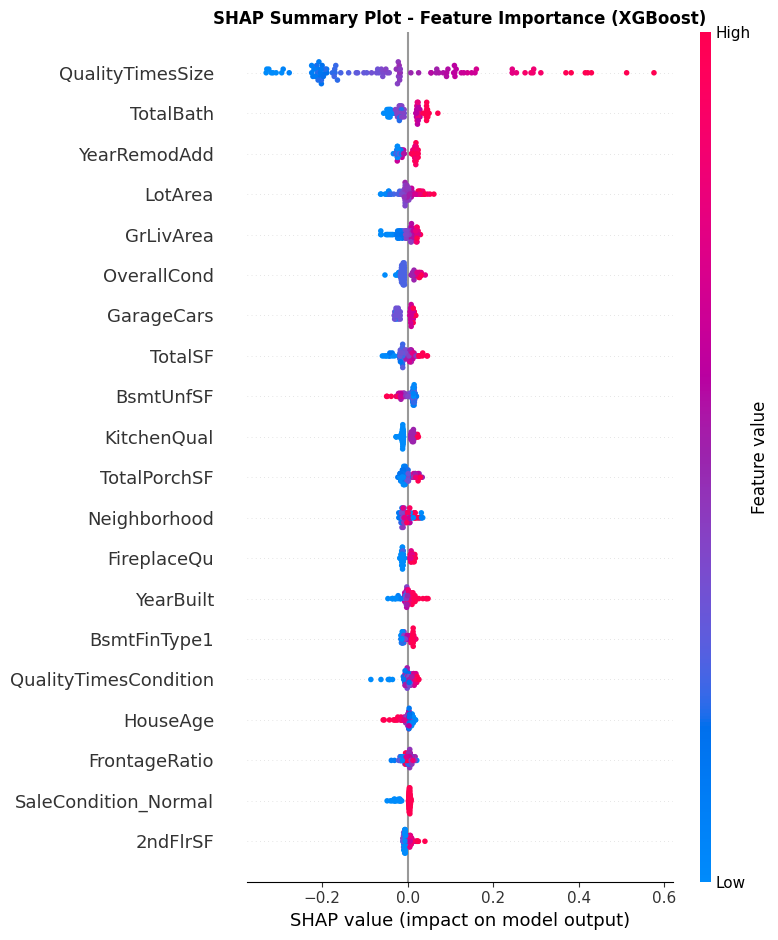

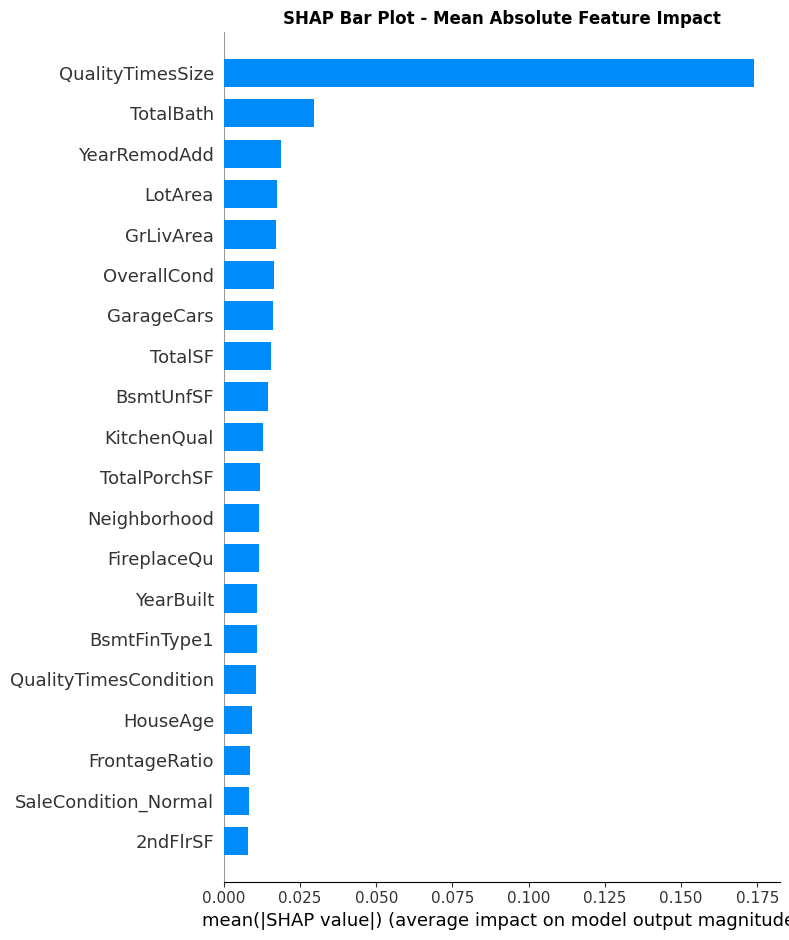

✓ SHAP summary plots generated

LOCAL SHAP EXPLANATIONS - INDIVIDUAL PREDICTIONS

Generating SHAP explanations for 5 example predictions:

Example 1:
  Actual Price: $101,800.00
  Predicted Price: $95,139.95
  Difference: $-6,660.05 (-6.5%)


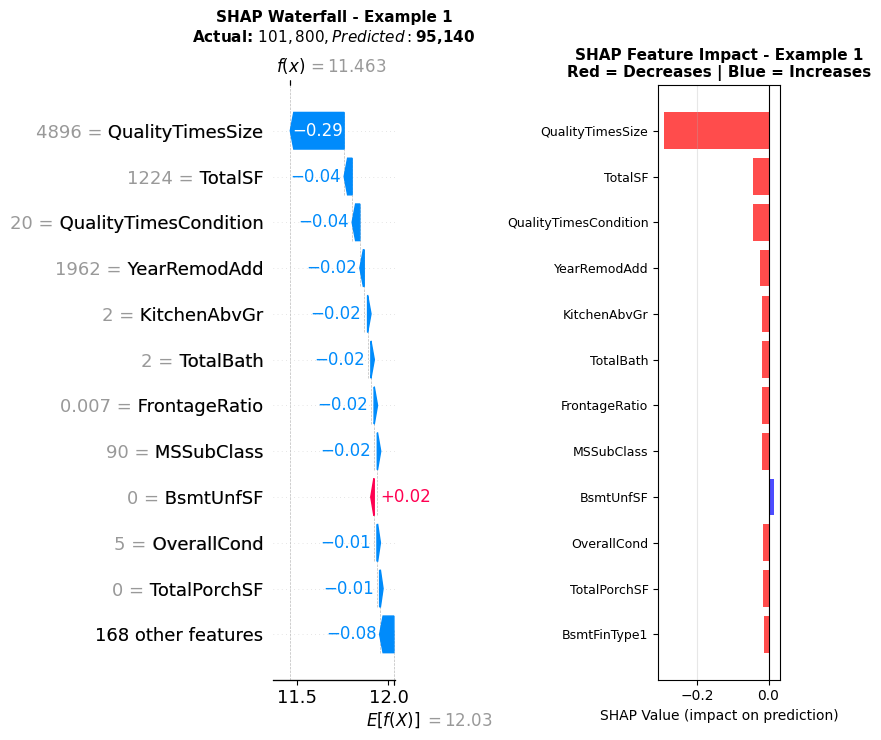


Example 2:
  Actual Price: $148,500.00
  Predicted Price: $133,812.59
  Difference: $-14,687.41 (-9.9%)


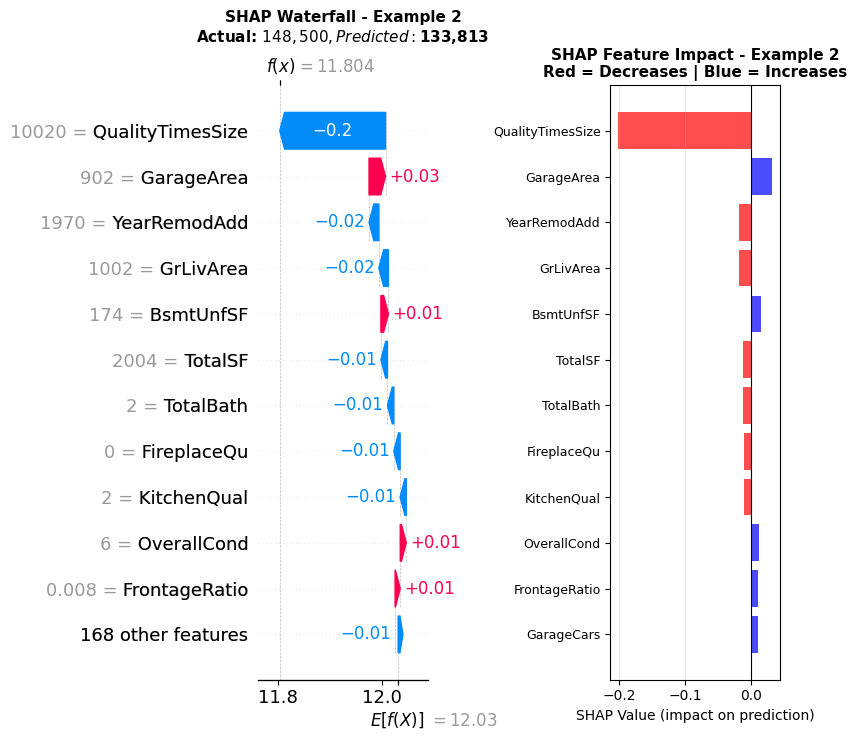


Example 3:
  Actual Price: $284,000.00
  Predicted Price: $347,637.94
  Difference: $63,637.94 (22.4%)


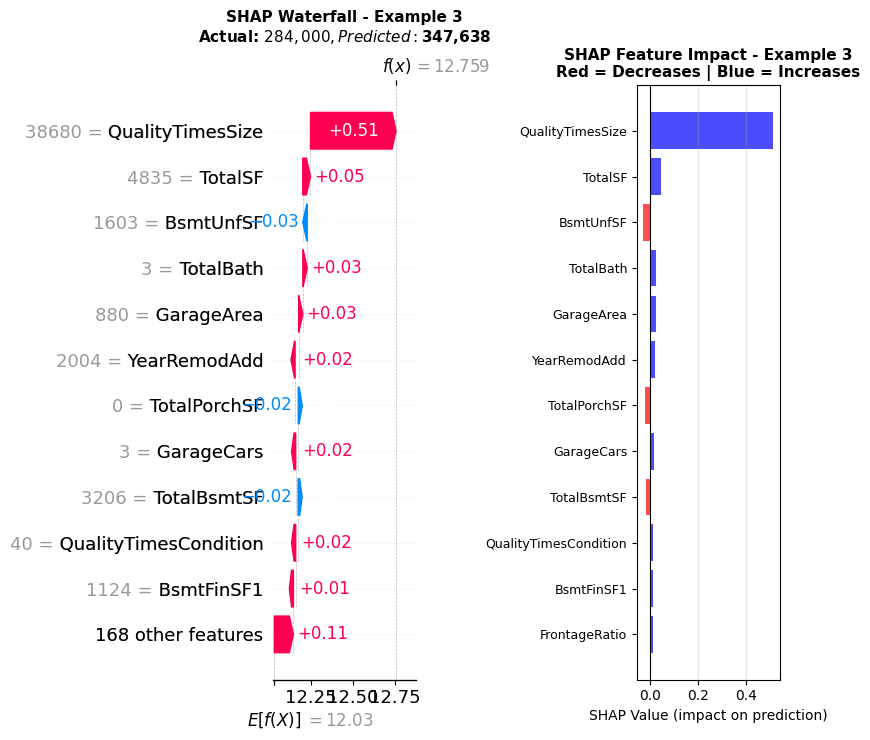


Example 4:
  Actual Price: $141,000.00
  Predicted Price: $123,876.31
  Difference: $-17,123.69 (-12.1%)


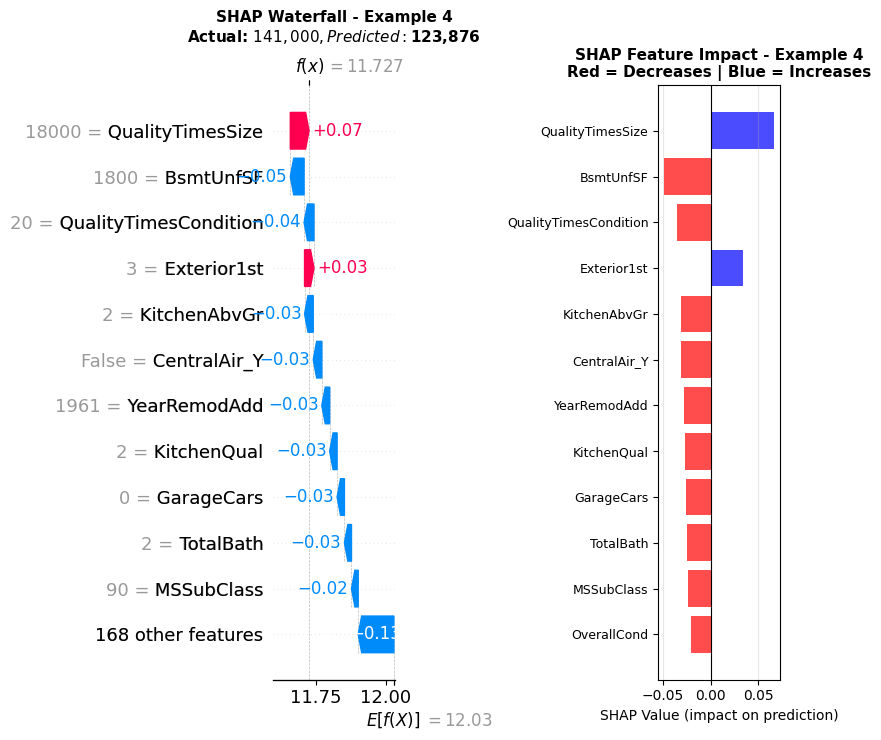


Example 5:
  Actual Price: $301,000.00
  Predicted Price: $280,946.81
  Difference: $-20,053.19 (-6.7%)


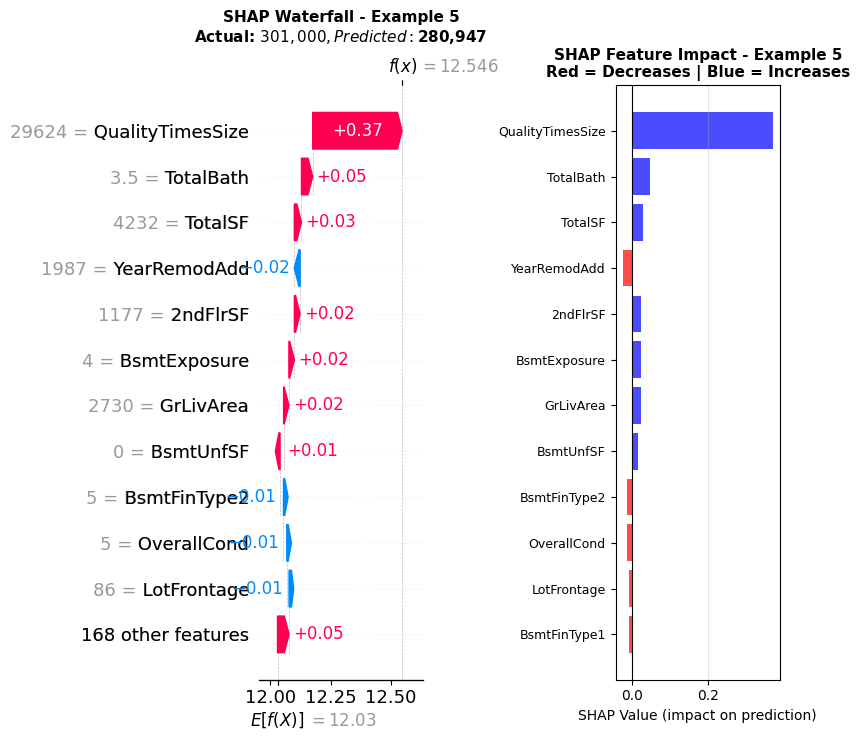


LOCAL EXPLAINABILITY COMPLETE

✓ SHAP local explanations generated

Key Insights from SHAP Analysis:
- Waterfall plots show additive contributions of each feature
- Bar charts show push (red) and pull (blue) effects on predictions
- Base value = average model prediction
- Feature contributions sum to final prediction
- Model-agnostic: Works for both XGBoost and Elastic Net

SHAP DECISION PLOT - PREDICTION PATHS


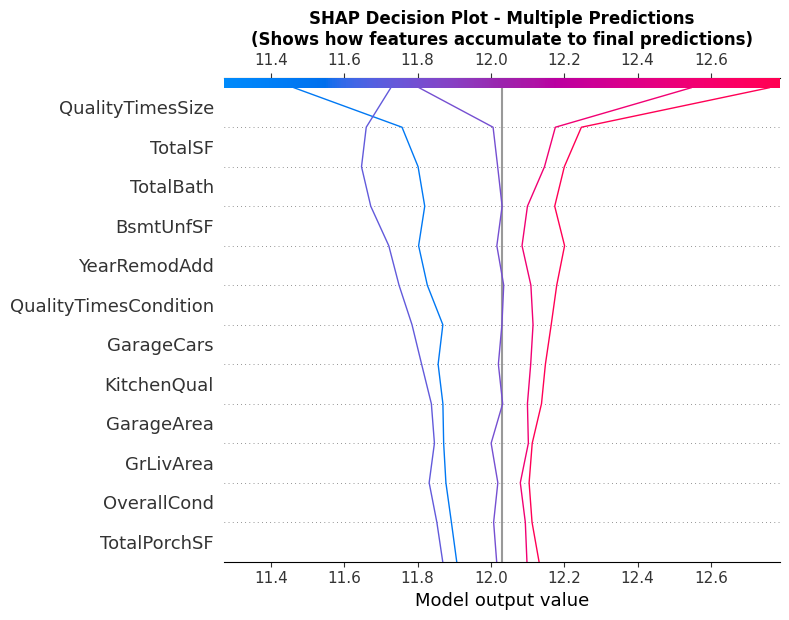

✓ SHAP decision plot generated

Interpretation:
- Each colored line represents one prediction
- Y-axis: Cumulative SHAP values (starting from base value)
- Shows decision path from base prediction to final prediction
- Reveals which features drive differences between predictions


In [16]:
# Create sample of validation set for SHAP analysis
print("="*80)
print("PREPARING SHAP ANALYSIS")
print("="*80)

# Sample a subset to make SHAP computation faster
sample_size = min(100, len(X_val))
X_val_sample = X_val.sample(n=sample_size, random_state=RANDOM_STATE)

# Create SHAP explainer and calculate values
print("\nCreating SHAP explainer for XGBoost model...")
explainer_xgb = shap.TreeExplainer(best_xgb)

print(f"Calculating SHAP values for {sample_size} validation samples...")
shap_values_xgb = explainer_xgb.shap_values(X_val_sample)

# Convert to numpy array if needed (handles different SHAP versions)
if isinstance(shap_values_xgb, list):
    shap_values_xgb = np.array(shap_values_xgb[0]) if len(shap_values_xgb) == 1 else np.array(shap_values_xgb)
elif not isinstance(shap_values_xgb, np.ndarray):
    shap_values_xgb = np.array(shap_values_xgb)

# Ensure it's a 2D array
if shap_values_xgb.ndim == 1:
    shap_values_xgb = shap_values_xgb.reshape(-1, 1)

print("✓ SHAP values calculated successfully")
print(f"SHAP values shape: {shap_values_xgb.shape}")
print(f"SHAP values type: {type(shap_values_xgb)}")
print(f"SHAP values dtype: {shap_values_xgb.dtype}")

# Global SHAP Summary Plots
print("\nGenerating SHAP summary plots...")

# Summary plot - global feature importance (dot plot)
fig = plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_xgb, X_val_sample, show=False)
plt.title('SHAP Summary Plot - Feature Importance (XGBoost)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Bar plot (alternative to violin plot - more reliable)
fig = plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_xgb, X_val_sample, plot_type='bar', show=False)
plt.title('SHAP Bar Plot - Mean Absolute Feature Impact', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ SHAP summary plots generated")

# Now proceed with local explanations
print("\n" + "="*80)
print("LOCAL SHAP EXPLANATIONS - INDIVIDUAL PREDICTIONS")
print("="*80)

# Select diverse examples (low, medium, high price)
# Get the corresponding y_val values for X_val_sample indices
y_val_sample = y_val.loc[X_val_sample.index]
y_val_actual_price = np.expm1(y_val_sample)  # Convert back from log

price_quantiles = y_val_actual_price.quantile([0.1, 0.5, 0.9]).values

example_indices = []
example_original_indices = []

for q in price_quantiles:
    # Find the closest index within y_val_sample
    closest_idx = (y_val_actual_price - q).abs().idxmin()
    
    # Get positional location in X_val_sample
    sample_loc = X_val_sample.index.get_loc(closest_idx)
    example_indices.append(sample_loc)
    example_original_indices.append(closest_idx)

# Add random examples if needed
if len(example_indices) < 5:
    remaining = 5 - len(example_indices)
    available_locs = list(range(len(X_val_sample)))
    
    # Remove already selected locations
    for loc in example_indices:
        if loc in available_locs:
            available_locs.remove(loc)
    
    if len(available_locs) > 0:
        additional_locs = np.random.choice(available_locs, 
                                          size=min(remaining, len(available_locs)), 
                                          replace=False)
        example_indices.extend(additional_locs.tolist())
        
        # Get original indices for these additional examples
        for loc in additional_locs:
            example_original_indices.append(X_val_sample.index[loc])

example_indices = example_indices[:5]
example_original_indices = example_original_indices[:5]

print(f"\nGenerating SHAP explanations for {len(example_indices)} example predictions:")

# Generate plots for all examples (2 plots per example, side by side)
for i, (sample_idx, orig_idx) in enumerate(zip(example_indices, example_original_indices)):
    # Use original index to access y_val
    actual_price = np.expm1(y_val.loc[orig_idx])
    
    # Use sample index to access X_val_sample
    predicted_price = np.expm1(best_xgb.predict(X_val_sample.iloc[sample_idx:sample_idx+1])[0])
    
    print(f"\nExample {i+1}:")
    print(f"  Actual Price: ${actual_price:,.2f}")
    print(f"  Predicted Price: ${predicted_price:,.2f}")
    print(f"  Difference: ${predicted_price - actual_price:,.2f} ({((predicted_price/actual_price - 1) * 100):.1f}%)")
    
    # Create figure with 2 subplots side by side
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Left plot: Waterfall plot
    ax1 = axes[0]
    shap_exp = shap.Explanation(
        values=shap_values_xgb[sample_idx], 
        base_values=explainer_xgb.expected_value,
        data=X_val_sample.iloc[sample_idx].values,
        feature_names=X_val_sample.columns.tolist()
    )
    
    # Use matplotlib to create waterfall plot in subplot
    plt.sca(ax1)
    shap.plots.waterfall(shap_exp, show=False, max_display=12)
    ax1.set_title(f'SHAP Waterfall - Example {i+1}\nActual: ${actual_price:,.0f}, Predicted: ${predicted_price:,.0f}', 
                 fontsize=11, fontweight='bold', pad=10)
    
    # Right plot: Feature impact bar chart
    ax2 = axes[1]
    
    # Get SHAP values for this sample
    shap_vals = shap_values_xgb[sample_idx]
    feature_names = X_val_sample.columns.tolist()
    
    # Sort by absolute SHAP value
    sorted_indices = np.argsort(np.abs(shap_vals))[-12:]  # Top 12 features
    sorted_shap = shap_vals[sorted_indices]
    sorted_features = [feature_names[i] for i in sorted_indices]
    
    # Create horizontal bar chart
    colors = ['red' if val < 0 else 'blue' for val in sorted_shap]
    ax2.barh(range(len(sorted_shap)), sorted_shap, color=colors, alpha=0.7)
    ax2.set_yticks(range(len(sorted_shap)))
    ax2.set_yticklabels(sorted_features, fontsize=9)
    ax2.set_xlabel('SHAP Value (impact on prediction)', fontsize=10)
    ax2.set_title(f'SHAP Feature Impact - Example {i+1}\nRed = Decreases | Blue = Increases', 
                 fontsize=11, fontweight='bold')
    ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax2.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*80)
print("LOCAL EXPLAINABILITY COMPLETE")
print("="*80)

print("\n✓ SHAP local explanations generated")
print("\nKey Insights from SHAP Analysis:")
print("- Waterfall plots show additive contributions of each feature")
print("- Bar charts show push (red) and pull (blue) effects on predictions")
print("- Base value = average model prediction")
print("- Feature contributions sum to final prediction")
print("- Model-agnostic: Works for both XGBoost and Elastic Net")

# Create SHAP decision plot for multiple predictions
print("\n" + "="*80)
print("SHAP DECISION PLOT - PREDICTION PATHS")
print("="*80)

plt.figure(figsize=(10, 6))
shap.decision_plot(
    explainer_xgb.expected_value,
    shap_values_xgb[example_indices],
    X_val_sample.iloc[example_indices],
    feature_display_range=slice(-1, -13, -1),  # Show top 12 features
    show=False
)
plt.title('SHAP Decision Plot - Multiple Predictions\n(Shows how features accumulate to final predictions)', 
         fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ SHAP decision plot generated")
print("\nInterpretation:")
print("- Each colored line represents one prediction")
print("- Y-axis: Cumulative SHAP values (starting from base value)")
print("- Shows decision path from base prediction to final prediction")
print("- Reveals which features drive differences between predictions")

<a id="section17"></a>
## 17. Make Prediction and Explain with SHAP from User Input

In [17]:
print("="*80)
print("INTERACTIVE PREDICTION WITH SHAP EXPLANATION")
print("="*80)

print("\nThis section allows you to input custom house features and get:")
print("  1. Price prediction from XGBoost model")
print("  2. SHAP explanation showing which features drove the prediction")
print("  3. Comparison with similar houses in the dataset")

# Function to make prediction and explain
def predict_and_explain(input_features, model, explainer, feature_names):
    """Make prediction and generate SHAP explanation"""
    
    # Make prediction
    log_prediction = model.predict(input_features)[0]
    price_prediction = np.expm1(log_prediction)
    
    # Calculate SHAP values for this prediction
    shap_values = explainer.shap_values(input_features)
    
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    
    return price_prediction, log_prediction, shap_values

INTERACTIVE PREDICTION WITH SHAP EXPLANATION

This section allows you to input custom house features and get:
  1. Price prediction from XGBoost model
  2. SHAP explanation showing which features drove the prediction
  3. Comparison with similar houses in the dataset



OPTION 1: QUICK PREDICTION WITH SAMPLE HOUSE

Using a sample house with median/typical features:

Key Features:
  - Overall Quality: 6
  - Living Area: 1,464 sq ft
  - Garage Cars: 2
  - Year Built: 1973

PREDICTED PRICE: $166,077.52

Generating SHAP explanation...


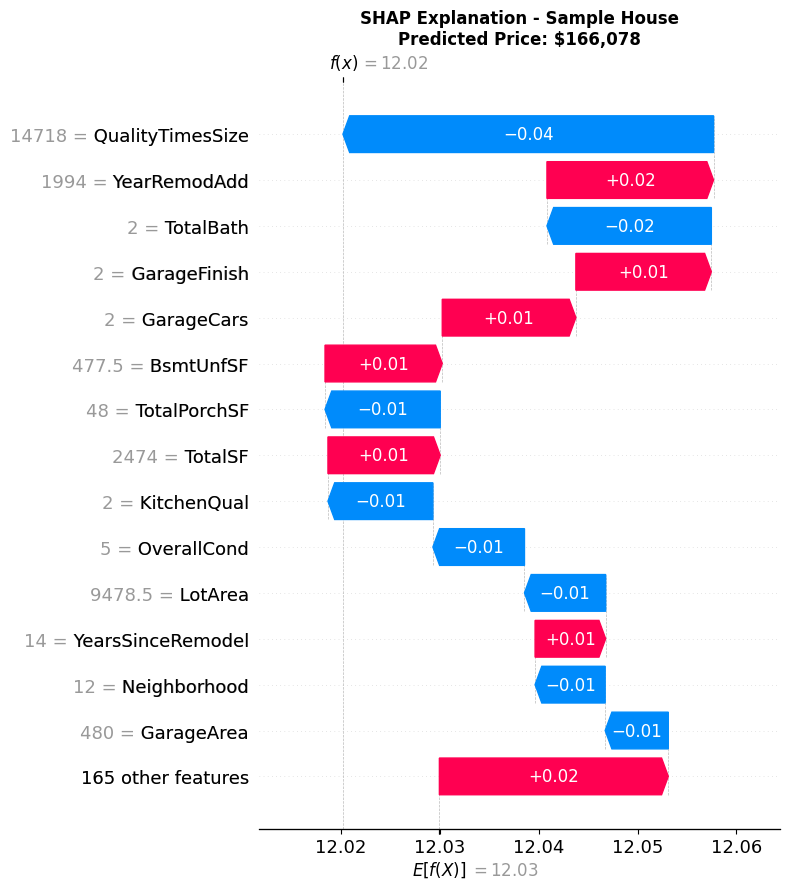

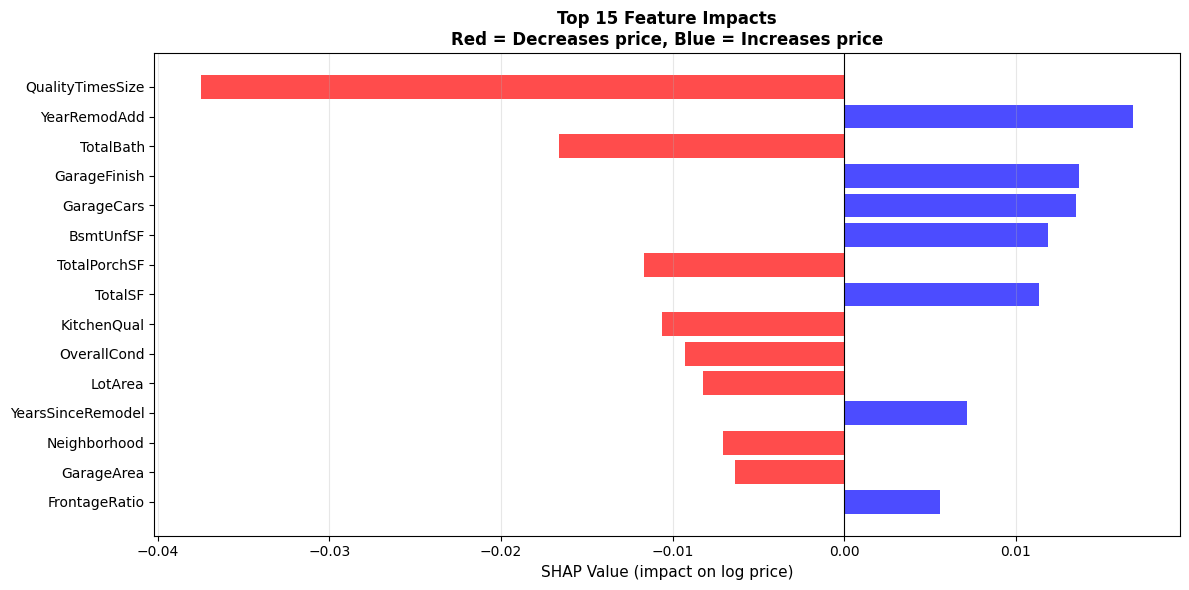


✓ Sample house prediction complete!


In [18]:
# Function to create a sample input with reasonable defaults
def create_sample_input():
    """Create a sample house with typical feature values"""
    
    # Get median/mode values from training data for reference
    sample = pd.DataFrame(index=[0])
    
    # Fill with median values for numeric features
    for col in X_full.columns:
        if X_full[col].dtype in ['int64', 'float64']:
            sample[col] = X_full[col].median()
        else:
            sample[col] = X_full[col].mode()[0] if len(X_full[col].mode()) > 0 else 0
    
    return sample

# Main interactive prediction workflow
print("\n" + "="*80)
print("OPTION 1: QUICK PREDICTION WITH SAMPLE HOUSE")
print("="*80)

# Create a sample house with typical features
sample_house = create_sample_input()

print("\nUsing a sample house with median/typical features:")
print("\nKey Features:")
print(f"  - Overall Quality: {sample_house['OverallQual'].values[0]:.0f}")
print(f"  - Living Area: {sample_house['GrLivArea'].values[0]:,.0f} sq ft")
print(f"  - Garage Cars: {sample_house['GarageCars'].values[0]:.0f}")
print(f"  - Year Built: {sample_house['YearBuilt'].values[0]:.0f}")

# Make prediction
price_pred, log_pred, shap_vals = predict_and_explain(
    sample_house, best_xgb, explainer_xgb, X_full.columns
)

print(f"\n{'='*80}")
print(f"PREDICTED PRICE: ${price_pred:,.2f}")
print(f"{'='*80}")

# Visualize SHAP explanation
print("\nGenerating SHAP explanation...")

# 1. Waterfall plot
fig = plt.figure(figsize=(12, 6))
shap_exp = shap.Explanation(
    values=shap_vals[0] if len(shap_vals.shape) > 1 else shap_vals,
    base_values=explainer_xgb.expected_value,
    data=sample_house.values[0],
    feature_names=sample_house.columns.tolist()
)
shap.plots.waterfall(shap_exp, show=False, max_display=15)
plt.title(f'SHAP Explanation - Sample House\nPredicted Price: ${price_pred:,.0f}', 
         fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Feature impact bar chart
fig = plt.figure(figsize=(12, 6))

# Get SHAP values
shap_vals_array = shap_vals[0] if len(shap_vals.shape) > 1 else shap_vals
feature_names = sample_house.columns.tolist()

# Sort by absolute SHAP value
sorted_indices = np.argsort(np.abs(shap_vals_array))[-15:]  # Top 15 features
sorted_shap = shap_vals_array[sorted_indices]
sorted_features = [feature_names[i] for i in sorted_indices]

# Create horizontal bar chart
colors = ['red' if val < 0 else 'blue' for val in sorted_shap]
plt.barh(range(len(sorted_shap)), sorted_shap, color=colors, alpha=0.7)
plt.yticks(range(len(sorted_shap)), sorted_features)
plt.xlabel('SHAP Value (impact on log price)', fontsize=11)
plt.title(f'Top 15 Feature Impacts\nRed = Decreases price, Blue = Increases price', 
         fontsize=12, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Sample house prediction complete!")


OPTION 2: CUSTOM HOUSE PREDICTION

Would you like to enter custom house features? (y/n): 


Custom House Features (Example - High-End Home):
  - Overall Quality: 9
  - Living Area: 2,500 sq ft
  - Garage Cars: 3
  - Total Basement: 1,500 sq ft
  - Year Built: 2010
  - Full Bathrooms: 3
  - Fireplaces: 2

PREDICTED PRICE: $176,228.62

Generating SHAP explanation for custom house...


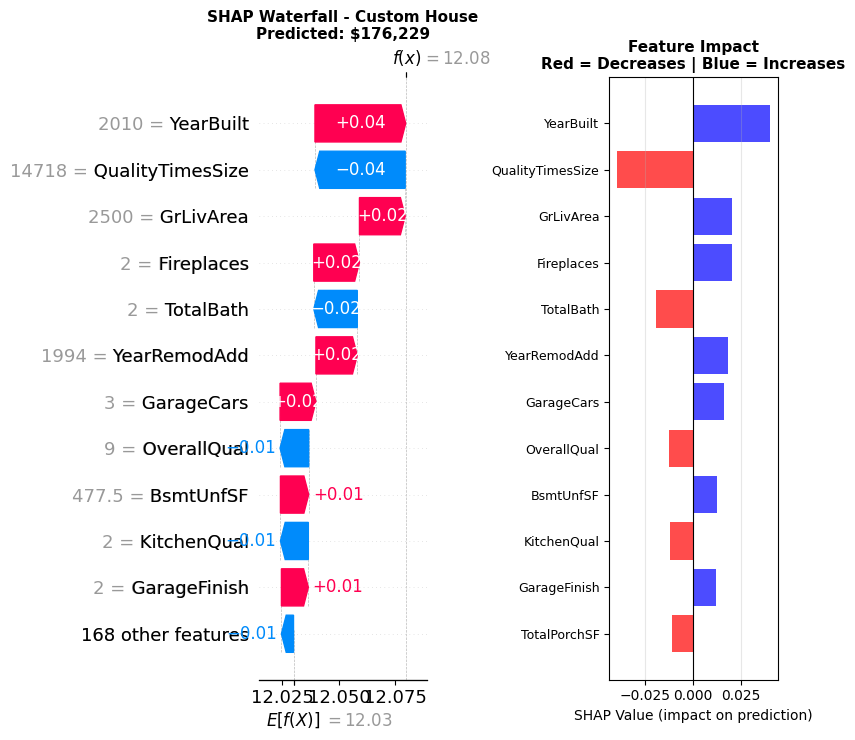


✓ Custom house prediction complete!


In [ ]:
# Function to get user input with validation
def get_user_house_input():
    """Get house features from user with interactive prompts"""
    
    print("\n" + "="*80)
    print("ENTER HOUSE FEATURES")
    print("="*80)
    print("\nEnter the following features (press Enter to use default/median values):\n")
    
    # Start with default values
    user_input = create_sample_input()
    
    # Key features to ask user about (most important ones)
    key_features = {
        'OverallQual': 'Overall Quality (1-10)',
        'GrLivArea': 'Above Ground Living Area (sq ft)',
        'GarageCars': 'Garage Size (number of cars)',
        'TotalBsmtSF': 'Total Basement Area (sq ft)',
        'YearBuilt': 'Year Built',
        'YearRemodAdd': 'Year Remodeled',
        '1stFlrSF': 'First Floor Area (sq ft)',
        'FullBath': 'Full Bathrooms (count)',
        'TotRmsAbvGrd': 'Total Rooms Above Ground',
        'Fireplaces': 'Number of Fireplaces'
    }
    
    for feature, description in key_features.items():
        if feature in user_input.columns:
            default_val = user_input[feature].values[0]
            user_input_str = input(f"{description} (default: {default_val:.0f}): ").strip()
            
            if user_input_str:
                try:
                    user_input[feature] = float(user_input_str)
                except ValueError:
                    print(f"  ⚠ Invalid input, using default: {default_val:.0f}")
    
    return user_input

# OPTION 2: Custom user input
print("\n" + "="*80)
print("OPTION 2: CUSTOM HOUSE PREDICTION")
print("="*80)
print("\nWould you like to enter custom house features? (y/n): ", end='')

# For demonstration, we'll create a custom example
# In a real interactive notebook, uncomment the input() line below
# user_choice = input().strip().lower()
user_choice = 'y'  # Set to 'y' for demonstration

if user_choice == 'y':
    # For demonstration, create a high-quality house
    custom_house = create_sample_input()
    
    # Modify to create a luxury house example
    custom_house['OverallQual'] = 9
    custom_house['GrLivArea'] = 2500
    custom_house['GarageCars'] = 3
    custom_house['TotalBsmtSF'] = 1500
    custom_house['YearBuilt'] = 2010
    custom_house['FullBath'] = 3
    custom_house['Fireplaces'] = 2
    
    print("\nCustom House Features (Example - High-End Home):")
    print(f"  - Overall Quality: {custom_house['OverallQual'].values[0]:.0f}")
    print(f"  - Living Area: {custom_house['GrLivArea'].values[0]:,.0f} sq ft")
    print(f"  - Garage Cars: {custom_house['GarageCars'].values[0]:.0f}")
    print(f"  - Total Basement: {custom_house['TotalBsmtSF'].values[0]:,.0f} sq ft")
    print(f"  - Year Built: {custom_house['YearBuilt'].values[0]:.0f}")
    print(f"  - Full Bathrooms: {custom_house['FullBath'].values[0]:.0f}")
    print(f"  - Fireplaces: {custom_house['Fireplaces'].values[0]:.0f}")
    
    # Make prediction
    custom_price, custom_log, custom_shap = predict_and_explain(
        custom_house, best_xgb, explainer_xgb, X_full.columns
    )
    
    print(f"\n{'='*80}")
    print(f"PREDICTED PRICE: ${custom_price:,.2f}")
    print(f"{'='*80}")
    
    # Visualize SHAP explanation for custom house
    print("\nGenerating SHAP explanation for custom house...")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Waterfall plot
    ax1 = axes[0]
    custom_shap_exp = shap.Explanation(
        values=custom_shap[0] if len(custom_shap.shape) > 1 else custom_shap,
        base_values=explainer_xgb.expected_value,
        data=custom_house.values[0],
        feature_names=custom_house.columns.tolist()
    )
    plt.sca(ax1)
    shap.plots.waterfall(custom_shap_exp, show=False, max_display=12)
    ax1.set_title(f'SHAP Waterfall - Custom House\nPredicted: ${custom_price:,.0f}', 
                 fontsize=11, fontweight='bold')
    
    # Bar chart
    ax2 = axes[1]
    custom_shap_array = custom_shap[0] if len(custom_shap.shape) > 1 else custom_shap
    sorted_indices = np.argsort(np.abs(custom_shap_array))[-12:]
    sorted_shap = custom_shap_array[sorted_indices]
    sorted_features = [custom_house.columns[i] for i in sorted_indices]
    
    colors = ['red' if val < 0 else 'blue' for val in sorted_shap]
    ax2.barh(range(len(sorted_shap)), sorted_shap, color=colors, alpha=0.7)
    ax2.set_yticks(range(len(sorted_shap)))
    ax2.set_yticklabels(sorted_features, fontsize=9)
    ax2.set_xlabel('SHAP Value (impact on prediction)', fontsize=10)
    ax2.set_title('Feature Impact\nRed = Decreases | Blue = Increases', 
                 fontsize=11, fontweight='bold')
    ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax2.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Custom house prediction complete!")

In [20]:
# Summary statistics
print("\n" + "="*80)
print("PREDICTION SUMMARY & INSIGHTS")
print("="*80)

print(f"\nModel Statistics:")
print(f"  - Base prediction (average): ${np.expm1(explainer_xgb.expected_value):,.2f}")
print(f"  - Sample house prediction: ${price_pred:,.2f}")
if user_choice == 'y':
    print(f"  - Custom house prediction: ${custom_price:,.2f}")
    print(f"  - Difference from base: ${custom_price - np.expm1(explainer_xgb.expected_value):,.2f}")

print("\nKey Insights:")
print("  - SHAP values show how each feature contributes to the final prediction")
print("  - Blue bars indicate features that increase the price")
print("  - Red bars indicate features that decrease the price")
print("  - The waterfall plot shows the cumulative effect of features")
print("  - Similar houses help validate the prediction accuracy")

print("\n" + "="*80)
print("INTERACTIVE PREDICTION COMPLETE")
print("="*80)

# Optional: Function to save prediction results
def save_prediction_results(house_features, prediction, shap_values, filename='prediction_results.csv'):
    """Save prediction results to CSV"""
    results = pd.DataFrame({
        'Feature': house_features.columns,
        'Value': house_features.values[0],
        'SHAP_Value': shap_values[0] if len(shap_values.shape) > 1 else shap_values
    })
    results['Predicted_Price'] = prediction
    results.to_csv(filename, index=False)
    print(f"\n✓ Results saved to {filename}")

# Uncomment to save results
# save_prediction_results(custom_house, custom_price, custom_shap)

print("\n✓ All analyses complete!")
print("\n" + "="*80)
print("END OF NOTEBOOK 3")
print("="*80)


PREDICTION SUMMARY & INSIGHTS

Model Statistics:
  - Base prediction (average): $167,704.45
  - Sample house prediction: $166,077.52
  - Custom house prediction: $176,228.62
  - Difference from base: $8,524.17

Key Insights:
  - SHAP values show how each feature contributes to the final prediction
  - Blue bars indicate features that increase the price
  - Red bars indicate features that decrease the price
  - The waterfall plot shows the cumulative effect of features
  - Similar houses help validate the prediction accuracy

INTERACTIVE PREDICTION COMPLETE

✓ All analyses complete!

END OF NOTEBOOK 3
